# GR-Prediction Frame-Rate LSTM — CREPE-style Discretized Output

Trains a **frame-rate LSTM** to predict the gain-reduction envelope of the
SSL G-Bus compressor from dry audio input, using a **CREPE-inspired
classification** approach over discrete dB bins.

## Architecture

```
dry audio [B,1,T]
  → strided conv encoder → features [B,C,T/hop]
    → LSTM (causal, unbounded memory) → [B,H,T/hop]
      → linear head → logits [B,NUM_BINS,T/hop]   (151 bins, 0.2 dB res)
        → sigmoid + local weighted avg → GR_db [B,1,T/hop]
          → linear interpolation → GR_db [B,1,T]
```

## CREPE-style Discretization

Instead of regressing a single dB value, the model classifies each frame
into one of **151 bins** spanning [−30, 0] dB at **0.2 dB resolution**.

| | Regression (previous) | Discretized (this notebook) |
|---|---|---|
| **Output** | 1 scalar (tanh → dB) | 151 logits (sigmoid → soft probs) |
| **Loss** | L1 in dB + diff L1 | Binary cross-entropy on Gaussian-blurred soft targets |
| **Inference** | Direct dB value | Local weighted average around argmax → continuous dB |
| **Advantage** | Simple | Captures multimodal uncertainty; sub-bin accuracy via averaging |

- **Gaussian soft targets** (σ = 2 bins = 0.4 dB) smooth the classification signal.
- **Local weighted average** (±5 bins around argmax) recovers continuous dB at inference.
- **No conditioning** — trains on a single parameter setting.
- **Dataset**: loaded from Google Drive, cached to Colab SSD.

**Runtime**: Select **GPU** via *Runtime → Change runtime type*.

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────
# Much lighter than the GCN notebook — no nablafx / auraloss / wandb needed.
!pip install -q lightning torchmetrics soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 62.7 MB/s eta 0:00:00


In [2]:
# ── 1. Mount Google Drive & locate dataset ───────────────────────────

import os
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

DRIVE_DATA_ROOT = None
SETTING = "threshold_-4_attack_1_release_0.4_ratio_10"

def _find_dataset_root() -> str | None:
    import glob as _g
    candidates = _g.glob("/content/drive/*/*/*/Diff-SSL-G-Comp", recursive=False)
    candidates += _g.glob("/content/drive/*/*/Diff-SSL-G-Comp")
    candidates += _g.glob("/content/drive/*/Diff-SSL-G-Comp")
    for c in candidates:
        if (os.path.isdir(os.path.join(c, "processed_normalized"))
                and os.path.isdir(os.path.join(c, "processed_ground_truth"))):
            return c
    return None

if DRIVE_DATA_ROOT is None:
    DRIVE_DATA_ROOT = _find_dataset_root()

DATA_ROOT = DRIVE_DATA_ROOT

if DATA_ROOT is None or not os.path.isdir(DATA_ROOT):
    print("Couldn't auto-find Diff-SSL-G-Comp. Here's what's under Drive:\n")
    import subprocess
    for top in ("Computers", "Othercomputers", "MyDrive", "Shareddrives"):
        p = f"/content/drive/{top}"
        if os.path.isdir(p):
            print(f"--- /content/drive/{top}/ ---")
            print(subprocess.check_output(["ls", p]).decode())
    raise AssertionError(
        "Dataset folder not found.\n"
        "Hard-set  DRIVE_DATA_ROOT = '/content/drive/.../Diff-SSL-G-Comp'  above."
    )

print(f"Auto-located dataset at: {DATA_ROOT}")

dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
wet_dir = os.path.join(DATA_ROOT, "processed_ground_truth", SETTING)
assert os.path.isdir(dry_dir), f"Missing dry folder: {dry_dir}"
assert os.path.isdir(wet_dir), f"Missing wet folder: {wet_dir}"

n_dry = len([f for f in os.listdir(dry_dir) if f.endswith(".wav")])
n_wet = len([f for f in os.listdir(wet_dir) if f.endswith(".wav")])
print(f"Dataset root : {DATA_ROOT}")
print(f"Setting      : {SETTING}")
print(f"Dry files    : {n_dry}")
print(f"Wet files    : {n_wet}")

OUTPUT_DIR = os.path.join(os.path.dirname(DATA_ROOT), "gr_pred_runs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Mounted at /content/drive
Auto-located dataset at: /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp
Dataset root : /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp
Setting      : threshold_-4_attack_1_release_0.4_ratio_10
Dry files    : 175
Wet files    : 10
Outputs will be saved to: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs


In [3]:
# ── 1b. Cache dataset to local SSD ───────────────────────────────────
# Copies dry WAVs and pre-computed GR curves (.pt) from Drive to the
# Colab local SSD for ~10–50× faster DataLoader I/O.

import shutil, time
from pathlib import Path
from google.colab import drive as _gdrive

LOCAL_DATA_ROOT = "/content/Diff-SSL-G-Comp"
USE_LOCAL_CACHE = True

def _remount_drive():
    try:
        _gdrive.flush_and_unmount()
    except Exception:
        pass
    _gdrive.mount("/content/drive", force_remount=True)

def _robust_copy(src: Path, dst: Path, max_retries: int = 5):
    for attempt in range(1, max_retries + 1):
        try:
            with open(src, "rb") as fsrc, open(dst, "wb") as fdst:
                shutil.copyfileobj(fsrc, fdst, length=1024 * 1024)
            return
        except OSError as e:
            print(f"  [retry {attempt}/{max_retries}] {src.name}: {e}")
            try: dst.unlink(missing_ok=True)
            except Exception: pass
            time.sleep(2 * attempt)
            if "Transport endpoint" in str(e) or e.errno in (107, 5):
                _remount_drive()
    raise RuntimeError(f"Failed to copy {src} after {max_retries} retries")

def _mirror_pair(src: Path, dst: Path, label: str, i: int, n: int):
    need_copy = not dst.exists() or dst.stat().st_size != src.stat().st_size
    if need_copy:
        _robust_copy(src, dst)
    print(f"  {label}: {i}/{n}  ({src.name}){'  [skip]' if not need_copy else ''}")

if USE_LOCAL_CACHE:
    local_dry = Path(LOCAL_DATA_ROOT) / "processed_normalized"
    local_dry.mkdir(parents=True, exist_ok=True)

    # 1) Discover songs from pre-computed GR curves
    gr_src_dir = Path(DATA_ROOT) / "gr_curves" / SETTING
    assert gr_src_dir.is_dir(), (
        f"No pre-computed GR curves at {gr_src_dir}.\n"
        f"Run locally: python gr_dataset.py --dataset diffssl"
    )
    pt_files = sorted(gr_src_dir.glob("*.pt"))
    songs = [p.stem for p in pt_files]
    print(f"Found {len(songs)} songs with GR curves for '{SETTING}':")
    for s in songs:
        print(f"  • {s}")

    # 2) Cache dry WAVs (only those with matching GR curves)
    print(f"\nCopying {len(songs)} dry files ...")
    for i, song in enumerate(songs, 1):
        dry_src = Path(dry_dir) / f"{song}_UnmasteredWAV.wav"
        dry_dst = local_dry    / f"{song}_UnmasteredWAV.wav"
        if not dry_src.exists():
            print(f"  WARNING: no dry file for '{song}' — skipping")
            continue
        _mirror_pair(dry_src, dry_dst, "dry", i, len(songs))

    # 3) Cache pre-computed GR curves (.pt files, ~33 MB each)
    local_gr = Path(LOCAL_DATA_ROOT) / "gr_curves" / SETTING
    local_gr.mkdir(parents=True, exist_ok=True)
    print(f"\nCopying {len(pt_files)} GR curve files ...")
    for i, pt_src in enumerate(pt_files, 1):
        _mirror_pair(pt_src, local_gr / pt_src.name, "gr", i, len(pt_files))

    DATA_ROOT = LOCAL_DATA_ROOT
    print(f"\nUsing local cache: {DATA_ROOT}")
else:
    print(f"Reading directly from Drive: {DATA_ROOT}")

Found 10 songs with GR curves for 'threshold_-4_attack_1_release_0.4_ratio_10':
  • Air
  • AncoraQui
  • BackroomInTulsa
  • Borderline
  • Ecstasy
  • Electrvm
  • LivingLie
  • NosPalpitants
  • OpenFire
  • SongForJohn

Copying 10 dry files ...
  dry: 1/10  (Air_UnmasteredWAV.wav)
  dry: 2/10  (AncoraQui_UnmasteredWAV.wav)
  dry: 3/10  (BackroomInTulsa_UnmasteredWAV.wav)
  dry: 4/10  (Borderline_UnmasteredWAV.wav)
  dry: 5/10  (Ecstasy_UnmasteredWAV.wav)
  dry: 6/10  (Electrvm_UnmasteredWAV.wav)
  dry: 7/10  (LivingLie_UnmasteredWAV.wav)
  dry: 8/10  (NosPalpitants_UnmasteredWAV.wav)
  dry: 9/10  (OpenFire_UnmasteredWAV.wav)
  dry: 10/10  (SongForJohn_UnmasteredWAV.wav)

Copying 10 GR curve files ...
  gr: 1/10  (Air.pt)
  gr: 2/10  (AncoraQui.pt)
  gr: 3/10  (BackroomInTulsa.pt)
  gr: 4/10  (Borderline.pt)
  gr: 5/10  (Ecstasy.pt)
  gr: 6/10  (Electrvm.pt)
  gr: 7/10  (LivingLie.pt)
  gr: 8/10  (NosPalpitants.pt)
  gr: 9/10  (OpenFire.pt)
  gr: 10/10  (SongForJohn.pt)

Using local

In [4]:
# ── 2. Upload src.dsp_torch into this Colab runtime ─────────────────

from pathlib import Path
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

_SRC_DSP_SOURCE = r'''PARAM_ORDER = ["threshold", "attack", "release", "ratio"]
PARAM_RANGES_LOCAL = {
    "threshold": (-20.0, 0.0),
    "attack": (0.1, 30.0),
    "release": (0.1, 1.6),
    "ratio": (2.0, 10.0),
}
'''

_SRC_DSP_TORCH_SOURCE = r'''"""
PyTorch-based DSP utilities: RMS envelopes, gain reduction, GR normalisation,
and compressor-parameter normalisation.
"""

import torch
import torch.nn.functional as F

from src.dsp import PARAM_ORDER, PARAM_RANGES_LOCAL

GR_DB_MIN = -30.0
GR_DB_MAX = 0.0
RMS_WINDOW = 1024


def windowed_rms(signal: torch.Tensor, window_size: int) -> torch.Tensor:
    orig_ndim = signal.ndim
    if orig_ndim == 1:
        sig = signal.view(1, 1, -1)
    elif orig_ndim == 2:
        sig = signal.unsqueeze(0)
    elif orig_ndim == 3:
        sig = signal
    else:
        raise ValueError(f"windowed_rms expects 1/2/3-D input, got {orig_ndim}-D")

    batch, channels, frames = sig.shape
    sq = sig.reshape(batch * channels, 1, frames) ** 2
    kernel = (
        torch.ones(1, 1, window_size, device=sig.device, dtype=sq.dtype)
        / window_size
    )
    pad = window_size - 1
    rms_sq = F.conv1d(sq, kernel, padding=pad)[..., :frames]
    rms = torch.sqrt(rms_sq.clamp(min=1e-10)).reshape(batch, channels, frames)

    if orig_ndim == 1:
        return rms.view(-1)
    if orig_ndim == 2:
        return rms.squeeze(0)
    return rms


def gain_reduction_db(
    dry: torch.Tensor, wet: torch.Tensor, window_size: int = RMS_WINDOW
) -> torch.Tensor:
    dry_rms = windowed_rms(dry, window_size)
    wet_rms = windowed_rms(wet, window_size)
    dry_db = 20 * torch.log10(dry_rms)
    wet_db = 20 * torch.log10(wet_rms)
    return wet_db - dry_db


def normalize_gr(gr_db: torch.Tensor) -> torch.Tensor:
    return (gr_db - GR_DB_MIN) / (GR_DB_MAX - GR_DB_MIN) * 2 - 1


def denormalize_gr(gr_norm: torch.Tensor) -> torch.Tensor:
    return (gr_norm + 1) / 2 * (GR_DB_MAX - GR_DB_MIN) + GR_DB_MIN


def compute_gr_target_norm(
    dry: torch.Tensor,
    wet: torch.Tensor,
    rms_window: int = RMS_WINDOW,
) -> torch.Tensor:
    gr_db = gain_reduction_db(dry.float(), wet.float(), rms_window)
    return normalize_gr(gr_db).clamp(-1.0, 1.0)


def gr_norm_to_db(gr_norm: torch.Tensor) -> torch.Tensor:
    return denormalize_gr(gr_norm)


def normalize_params(
    threshold: float,
    attack: float,
    release: float,
    ratio: float,
    ranges: dict | None = None,
) -> torch.Tensor:
    if ranges is None:
        ranges = PARAM_RANGES_LOCAL
    raw = torch.tensor([threshold, attack, release, ratio], dtype=torch.float32)
    for i, key in enumerate(PARAM_ORDER):
        lo, hi = ranges[key]
        raw[i] = (raw[i] - lo) / (hi - lo)
    return raw.clamp(0, 1)
'''

_src_dir = Path("/content/src")
_src_dir.mkdir(parents=True, exist_ok=True)
(_src_dir / "__init__.py").write_text("")
(_src_dir / "dsp.py").write_text(_SRC_DSP_SOURCE)
(_src_dir / "dsp_torch.py").write_text(_SRC_DSP_TORCH_SOURCE)
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

from src.dsp_torch import (
    GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
    gain_reduction_db,
)

print(f"Uploaded src.dsp_torch helpers to {_src_dir / 'dsp_torch.py'}")

NVIDIA L4
Uploaded src.dsp_torch helpers to /content/src/dsp_torch.py


In [5]:
# ── 3. Dataset & DataModule (pre-computed GR curves) ─────────────────
#
# Loads dry audio from WAVs + pre-computed GR envelopes (dB) from .pt
# files exported by gr_dataset.py.  GR curves are cached in RAM at
# setup (~33 MB per song at 44.1 kHz).
#
# Returns (dry [1,T], gr_db [1,T]).  The Lightning system uses GR
# directly in dB space (no normalisation).

import glob
import soundfile as sf
import torchaudio
import lightning as pl
from torch.utils.data import Dataset, DataLoader
from typing import Optional

SAMPLE_RATE = 44100
SAMPLE_LENGTH = 441000   # 10 s
SAMPLE_STRIDE = 110250   # 2.5 s


class PrecomputedGRDataset(Dataset):
    def __init__(
        self,
        data_root: str,
        settings_folder: str,
        sample_length: int = SAMPLE_LENGTH,
        sample_stride: int = SAMPLE_STRIDE,
        sample_rate: int = SAMPLE_RATE,
        random_crop: bool = False,
        samples: list[dict] | None = None,
        _gr_cache: dict | None = None,
    ):
        self.data_root = data_root
        self.settings_folder = settings_folder
        self.sample_length = sample_length
        self.sample_stride = sample_stride
        self.sample_rate = sample_rate
        self.random_crop = random_crop

        if samples is not None:
            self.samples = samples
            self._gr_cache = _gr_cache or {}
            return

        dry_dir = os.path.join(data_root, "processed_normalized")
        gr_dir = os.path.join(data_root, "gr_curves", settings_folder)
        assert os.path.isdir(gr_dir), f"No pre-computed GR at {gr_dir}"

        dry_lookup: dict[str, str] = {}
        for p in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav"))):
            song = os.path.basename(p).replace("_UnmasteredWAV.wav", "")
            dry_lookup[song] = p

        self._gr_cache: dict[str, torch.Tensor] = {}
        for pt_file in sorted(glob.glob(os.path.join(gr_dir, "*.pt"))):
            song = os.path.splitext(os.path.basename(pt_file))[0]
            if song in dry_lookup:
                rec = torch.load(pt_file, weights_only=False)
                self._gr_cache[song] = rec["gr_db"]

        self.samples: list[dict] = []
        for song in sorted(self._gr_cache.keys()):
            n_frames = int(self._gr_cache[song].shape[-1])
            dry_path = dry_lookup[song]
            if sample_length == -1:
                self.samples.append({
                    "song": song, "dry": dry_path,
                    "offset": 0, "frames": n_frames, "n_frames": n_frames,
                })
                continue
            if n_frames < sample_length:
                continue
            max_start = n_frames - sample_length
            for offset in range(0, max_start + 1, sample_stride):
                self.samples.append({
                    "song": song, "dry": dry_path,
                    "offset": offset, "frames": sample_length,
                    "n_frames": n_frames,
                })
            if self.samples[-1]["offset"] != max_start:
                self.samples.append({
                    "song": song, "dry": dry_path,
                    "offset": max_start, "frames": sample_length,
                    "n_frames": n_frames,
                })

        cache_mb = sum(t.numel() * 4 for t in self._gr_cache.values()) / 1024 / 1024
        print(
            f"PrecomputedGRDataset: {len(self._gr_cache)} songs, "
            f"{len(self.samples)} crops, {cache_mb:.0f} MB cached  "
            f"[setting={settings_folder}]"
        )

    def with_samples(self, samples, random_crop):
        return PrecomputedGRDataset(
            data_root=self.data_root,
            settings_folder=self.settings_folder,
            sample_length=self.sample_length,
            sample_stride=self.sample_stride,
            sample_rate=self.sample_rate,
            random_crop=random_crop,
            samples=samples,
            _gr_cache=self._gr_cache,
        )

    def __len__(self):
        return len(self.samples)

    def _crop_offset(self, sample):
        if self.sample_length == -1 or not self.random_crop:
            return sample["offset"]
        max_start = max(0, sample["n_frames"] - sample["frames"])
        return int(torch.randint(0, max_start + 1, ()).item()) if max_start > 0 else 0

    def __getitem__(self, idx):
        s = self.samples[idx]
        offset = self._crop_offset(s)
        nf = s["frames"] if self.sample_length != -1 else s["n_frames"]

        dry, sr = sf.read(
            s["dry"], start=offset, stop=offset + nf,
            dtype="float32", always_2d=True,
        )
        dry = torch.from_numpy(dry.T)
        if sr != self.sample_rate:
            dry = torchaudio.functional.resample(dry, sr, self.sample_rate)
        if dry.shape[0] > 1:
            dry = dry.mean(dim=0, keepdim=True)

        gr_db = self._gr_cache[s["song"]][..., offset:offset + nf]
        min_len = min(dry.shape[-1], gr_db.shape[-1])
        return dry[..., :min_len], gr_db[..., :min_len]


class GainReductionDataModule(pl.LightningDataModule):
    def __init__(
        self,
        data_root: str,
        settings_folder: str,
        sample_length: int = SAMPLE_LENGTH,
        sample_stride: int = SAMPLE_STRIDE,
        sample_rate: int = SAMPLE_RATE,
        train_split: float = 0.8,
        batch_size: int = 16,
        num_workers: int = 2,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.data_root = data_root
        self.settings_folder = settings_folder
        self.sample_length = sample_length
        self.sample_stride = sample_stride
        self.sample_rate = sample_rate
        self.train_split = train_split
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage: Optional[str] = None) -> None:
        full = PrecomputedGRDataset(
            data_root=self.data_root,
            settings_folder=self.settings_folder,
            sample_length=self.sample_length,
            sample_stride=self.sample_stride,
            sample_rate=self.sample_rate,
            random_crop=False,
        )

        songs = sorted({s["song"] for s in full.samples})
        if len(songs) < 2:
            raise ValueError("Need >= 2 songs for train/val split.")
        generator = torch.Generator().manual_seed(42)
        perm = torch.randperm(len(songs), generator=generator).tolist()
        n_train = int(len(songs) * self.train_split)
        n_train = min(max(1, n_train), len(songs) - 1)
        train_songs = {songs[i] for i in perm[:n_train]}
        val_songs = set(songs) - train_songs

        self.train_dataset = full.with_samples(
            [s for s in full.samples if s["song"] in train_songs], random_crop=True)
        self.val_dataset = full.with_samples(
            [s for s in full.samples if s["song"] in val_songs], random_crop=False)
        print(
            f"Train: {len(self.train_dataset)} crops from "
            f"{len(train_songs)} songs {sorted(train_songs)}"
        )
        print(
            f"Val:   {len(self.val_dataset)} crops from "
            f"{len(val_songs)} songs {sorted(val_songs)}"
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, batch_size=self.batch_size, shuffle=True,
            num_workers=self.num_workers, pin_memory=True, drop_last=True,
            persistent_workers=self.num_workers > 0,
            prefetch_factor=4 if self.num_workers > 0 else None,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=True,
            persistent_workers=self.num_workers > 0,
            prefetch_factor=4 if self.num_workers > 0 else None,
        )

In [6]:
# ── 4. Frame-Rate LSTM Model (CREPE-style discretized output) ────────
#
# 151 bins spanning [-30, 0] dB at 0.2 dB resolution.
# Training: BCE on Gaussian-blurred soft targets.
# Inference: sigmoid → local weighted average around argmax → continuous dB.

GR_NUM_BINS = 151
GR_BIN_RESOLUTION = 0.2
GR_BIN_CENTERS = torch.linspace(GR_DB_MIN, GR_DB_MAX, GR_NUM_BINS)


def gr_db_to_soft_target(gr_db: torch.Tensor, sigma_bins: float = 2.0) -> torch.Tensor:
    """Gaussian-blurred soft targets over GR bins (CREPE-style).

    Args:
        gr_db: [B, 1, T] continuous GR in dB
        sigma_bins: Gaussian spread in bin units (2.0 → σ = 0.4 dB)

    Returns:
        [B, NUM_BINS, T] soft target probabilities in [0, 1]
    """
    centers = GR_BIN_CENTERS.to(gr_db.device)
    diff = gr_db - centers[None, :, None]
    sigma_db = sigma_bins * GR_BIN_RESOLUTION
    return torch.exp(-0.5 * (diff / sigma_db) ** 2)


def logits_to_local_avg_db(logits: torch.Tensor, window: int = 5) -> torch.Tensor:
    """Convert bin logits to continuous dB via local weighted average.

    Args:
        logits: [B, NUM_BINS, T] raw logits
        window: half-window around argmax for local averaging (±window bins)

    Returns:
        [B, 1, T] continuous dB estimates
    """
    probs = torch.sigmoid(logits)
    centers = GR_BIN_CENTERS.to(logits.device)

    peak = probs.argmax(dim=1)  # [B, T]
    B, N, T = probs.shape

    bin_idx = torch.arange(N, device=logits.device).view(1, N, 1).expand(B, N, T)
    lo = (peak.unsqueeze(1) - window).clamp(min=0)
    hi = (peak.unsqueeze(1) + window + 1).clamp(max=N)
    mask = (bin_idx >= lo) & (bin_idx < hi)

    masked_probs = probs * mask
    weighted = (masked_probs * centers[None, :, None]).sum(dim=1, keepdim=True)
    total = masked_probs.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return weighted / total


class FrameRateLSTMGR(nn.Module):
    """Frame-rate LSTM for GR prediction with CREPE-style discretized output."""

    def __init__(
        self,
        hop_size: int = 256,
        encoder_channels: int = 32,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        num_bins: int = GR_NUM_BINS,
    ):
        super().__init__()
        self.hop_size = hop_size
        self.num_bins = num_bins
        self.rf = hop_size * 4

        ks = hop_size * 2
        self.encoder = nn.Sequential(
            nn.Conv1d(1, encoder_channels, ks, stride=hop_size, padding=ks // 2),
            nn.PReLU(encoder_channels),
            nn.Conv1d(encoder_channels, encoder_channels, 3, padding=1),
            nn.PReLU(encoder_channels),
        )

        self.lstm = nn.LSTM(
            encoder_channels, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_bins),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns raw logits at frame rate: [B, NUM_BINS, T/hop]."""
        feat = self.encoder(x)
        feat = feat.transpose(1, 2)
        h, _ = self.lstm(feat)
        logits = self.head(h)
        return logits.transpose(1, 2)

    def to_db(self, logits: torch.Tensor, T: int | None = None) -> torch.Tensor:
        """Convert logits → continuous dB, optionally upsampled to T samples."""
        db = logits_to_local_avg_db(logits)
        if T is not None:
            db = F.interpolate(db, size=T, mode="linear", align_corners=False)
        return db

    def reset_states(self):
        pass

In [7]:
# ── 5. Lightning System ──────────────────────────────────────────────
#
# CREPE-style training:
#   - Target GR (dB) is average-pooled to frame rate, then converted to
#     Gaussian-blurred soft labels over 151 bins.
#   - Loss: binary cross-entropy (sigmoid on logits vs soft targets).
#   - Also logs L1 dB MAE (via local weighted avg) for interpretability.

from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor


class GRPredictionLSTM(pl.LightningModule):

    def __init__(
        self,
        model: nn.Module,
        lr: float = 1e-3,
        sigma_bins: float = 2.0,
        warmup_frames: int = 4,
        lr_patience: int = 20,
        min_lr: float = 1e-6,
    ):
        super().__init__()
        self.model = model
        self.lr = lr
        self.sigma_bins = sigma_bins
        self.warmup_frames = warmup_frames
        self.lr_patience = lr_patience
        self.min_lr = min_lr

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def _step(self, batch: tuple, mode: str) -> torch.Tensor:
        dry, gr_db = batch
        gr_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX)

        if hasattr(self.model, "reset_states"):
            self.model.reset_states()
        logits = self(dry)  # [B, NUM_BINS, T_frames]

        T_frames = logits.shape[-1]
        gr_db_frames = F.adaptive_avg_pool1d(gr_db, T_frames)

        soft_target = gr_db_to_soft_target(gr_db_frames, sigma_bins=self.sigma_bins)

        w = self.warmup_frames
        logits = logits[..., w:]
        soft_target = soft_target[..., w:]
        gr_db_frames = gr_db_frames[..., w:]

        loss = F.binary_cross_entropy_with_logits(logits, soft_target)

        with torch.no_grad():
            pred_db = logits_to_local_avg_db(logits)
            mae_db = F.l1_loss(pred_db, gr_db_frames)

        self.log(f"loss/{mode}", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(f"mae_db/{mode}", mae_db, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._step(batch, "val")

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}

In [8]:
# ── 6. Train ─────────────────────────────────────────────────────────

import time, json, hashlib
from datetime import datetime
from lightning.pytorch.callbacks import EarlyStopping, TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

# ╔══════════════════════════════════════════════════════════════════╗
# ║ RESUME                                                           ║
# ╚══════════════════════════════════════════════════════════════════╝
RESUME_RUN: str | None = None
RUN_TAG: str = "lstm_v3_discretized"

# ── hparams ──────────────────────────────────────────────────────────
BATCH_SIZE            = 16
LR                    = 1e-3
MAX_EPOCHS            = 1000
EARLY_STOP_PATIENCE   = 50
LR_PLATEAU_PATIENCE   = 20
CKPT_EVERY_N_EPOCHS   = 5
SIGMA_BINS            = 2.0    # Gaussian target width in bin units (0.4 dB)

HOP_SIZE              = 256    # frame rate ≈ 172 Hz
ENCODER_CHANNELS      = 32
HIDDEN_SIZE           = 64
NUM_LAYERS            = 2
DROPOUT               = 0.0
# ─────────────────────────────────────────────────────────────────────

if RESUME_RUN:
    RUN_NAME = RESUME_RUN
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = os.path.join(RUN_DIR, "checkpoints", "last.ckpt")
    assert os.path.isfile(_resume_ckpt), f"No last.ckpt in {RUN_DIR}"
    print(f"RESUMING run: {RUN_NAME}\n  from ckpt: {_resume_ckpt}")
else:
    _ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_NAME = f"lstm_gr_{_ts}_{RUN_TAG}" if RUN_TAG else f"lstm_gr_{_ts}"
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = None
    print(f"NEW run: {RUN_NAME}")

os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run dir: {RUN_DIR}")

assert "/drive/" not in DATA_ROOT, (
    f"DATA_ROOT still points at Drive ({DATA_ROOT}). Run cell 1b first."
)

dm = GainReductionDataModule(
    data_root=DATA_ROOT,
    settings_folder=SETTING,
    sample_length=SAMPLE_LENGTH,
    sample_stride=SAMPLE_STRIDE,
    sample_rate=SAMPLE_RATE,
    train_split=0.8,
    batch_size=BATCH_SIZE,
    num_workers=2,
)

lstm = FrameRateLSTMGR(
    hop_size=HOP_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_bins=GR_NUM_BINS,
)

n_params = sum(p.numel() for p in lstm.parameters())
frame_rate = SAMPLE_RATE / HOP_SIZE
seq_len_frames = SAMPLE_LENGTH // HOP_SIZE
print(f"LSTM frame rate  : {frame_rate:.1f} Hz (hop={HOP_SIZE})")
print(f"Sequence length  : {seq_len_frames} frames per 10 s crop")
print(f"Output bins      : {GR_NUM_BINS} ({GR_BIN_RESOLUTION} dB resolution)")
print(f"Parameters       : {n_params:,}")

# ── save hparams ─────────────────────────────────────────────────────
_src_sha = hashlib.sha256(_SRC_DSP_TORCH_SOURCE.encode()).hexdigest()
_hparams = {
    "sample_rate": SAMPLE_RATE,
    "sample_length": SAMPLE_LENGTH,
    "sample_stride": SAMPLE_STRIDE,
    "rms_window": RMS_WINDOW,
    "gr_db_min": GR_DB_MIN,
    "gr_db_max": GR_DB_MAX,
    "setting": SETTING,
    "src_dsp_torch_sha256": _src_sha,
    "batch_size": BATCH_SIZE,
    "split_unit": "song",
    "split_seed": 42,
    "train_split": 0.8,
    "lr": LR,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "lr_plateau_patience": LR_PLATEAU_PATIENCE,
    "loss": {
        "kind": "bce_gaussian_soft_targets",
        "sigma_bins": SIGMA_BINS,
        "warmup_frames": 4,
        "local_avg_window": 5,
    },
    "model_type": "frame_rate_lstm_discretized",
    "discretization": {
        "num_bins": GR_NUM_BINS,
        "bin_resolution_db": GR_BIN_RESOLUTION,
        "range_db": [GR_DB_MIN, GR_DB_MAX],
    },
    "lstm": {
        "hop_size": HOP_SIZE,
        "encoder_channels": ENCODER_CHANNELS,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "frame_rate_hz": frame_rate,
        "seq_len_frames": seq_len_frames,
        "num_params": n_params,
    },
}
with open(os.path.join(RUN_DIR, "hparams.json"), "w") as _f:
    json.dump(_hparams, _f, indent=2)
print(f"Saved hparams.json")

system = GRPredictionLSTM(
    model=lstm,
    lr=LR,
    sigma_bins=SIGMA_BINS,
    lr_patience=LR_PLATEAU_PATIENCE,
)

# ── callbacks ────────────────────────────────────────────────────────
ckpt_dir = os.path.join(RUN_DIR, "checkpoints")

best_cb = ModelCheckpoint(
    dirpath=ckpt_dir, monitor="loss/val", mode="min",
    save_top_k=3, save_last=True,
    filename="best-{epoch:03d}-{step}",
    auto_insert_metric_name=False,
)
periodic_cb = ModelCheckpoint(
    dirpath=ckpt_dir, every_n_epochs=CKPT_EVERY_N_EPOCHS,
    save_top_k=-1, filename="epoch-{epoch:03d}",
    auto_insert_metric_name=False,
)
lr_cb = LearningRateMonitor(logging_interval="epoch")
early_stop_cb = EarlyStopping(
    monitor="loss/val", mode="min",
    patience=EARLY_STOP_PATIENCE, min_delta=0.0, verbose=True,
)

# ── loggers ──────────────────────────────────────────────────────────
tb_logger = TensorBoardLogger(save_dir=RUN_DIR, name="tb", version="")
csv_logger = CSVLogger(save_dir=RUN_DIR, name="csv", version="")

NEW run: lstm_gr_20260520_121432_lstm_v3_discretized
Run dir: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260520_121432_lstm_v3_discretized
LSTM frame rate  : 172.3 Hz (hop=256)
Sequence length  : 1722 frames per 10 s crop
Output bins      : 151 (0.2 dB resolution)
Parameters       : 85,015
Saved hparams.json


In [9]:
# ── 7. Launch TensorBoard & fit ──────────────────────────────────────

_tb_link = "/content/tb_current"
if os.path.islink(_tb_link) or os.path.exists(_tb_link):
    os.remove(_tb_link)
os.symlink(os.path.join(RUN_DIR, "tb"), _tb_link)

%load_ext tensorboard
%tensorboard --logdir /content/tb_current

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    precision="16-mixed",
    callbacks=[best_cb, periodic_cb, lr_cb, early_stop_cb,
               TQDMProgressBar(refresh_rate=10)],
    logger=[tb_logger, csv_logger],
    log_every_n_steps=10,
    default_root_dir=RUN_DIR,
    gradient_clip_val=1.0,
)

system.train()
system.model.train()

t0 = time.time()
trainer.fit(system, dm, ckpt_path=_resume_ckpt)
print(f"\nTotal training time: {(time.time() - t0)/60:.1f} min")
print(f"Best val loss: {best_cb.best_model_score:.4f}")
print(f"Best ckpt    : {best_cb.best_model_path}")
print(f"Last ckpt    : {best_cb.last_model_path}")

<IPython.core.display.Javascript object>

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


PrecomputedGRDataset: 10 songs, 1033 crops, 445 MB cached  [setting=threshold_-4_attack_1_release_0.4_ratio_10]
Train: 849 crops from 8 songs ['Air', 'AncoraQui', 'BackroomInTulsa', 'Ecstasy', 'Electrvm', 'LivingLie', 'OpenFire', 'SongForJohn']
Val:   184 crops from 2 songs ['Borderline', 'NosPalpitants']


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ FrameRateLSTMGR │ 85.0 K │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric loss/val did not improve in the last 50 records. Best score: 0.076. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric loss/val did not improve in the last 50 records. Best score: 0.076. Signaling Trainer to stop.



Total training time: 17.3 min
Best val loss: 0.0756
Best ckpt    : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260520_121432_lstm_v3_discretized/checkpoints/best-085-4558.ckpt
Last ckpt    : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260520_121432_lstm_v3_discretized/checkpoints/last.ckpt


Loaded best checkpoint: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260520_121432_lstm_v3_discretized/checkpoints/best-085-4558.ckpt
PrecomputedGRDataset: 10 songs, 1033 crops, 445 MB cached  [setting=threshold_-4_attack_1_release_0.4_ratio_10]
Train: 849 crops from 8 songs ['Air', 'AncoraQui', 'BackroomInTulsa', 'Ecstasy', 'Electrvm', 'LivingLie', 'OpenFire', 'SongForJohn']
Val:   184 crops from 2 songs ['Borderline', 'NosPalpitants']
Saved plot → /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260520_121432_lstm_v3_discretized/eval_gr_comparison.png


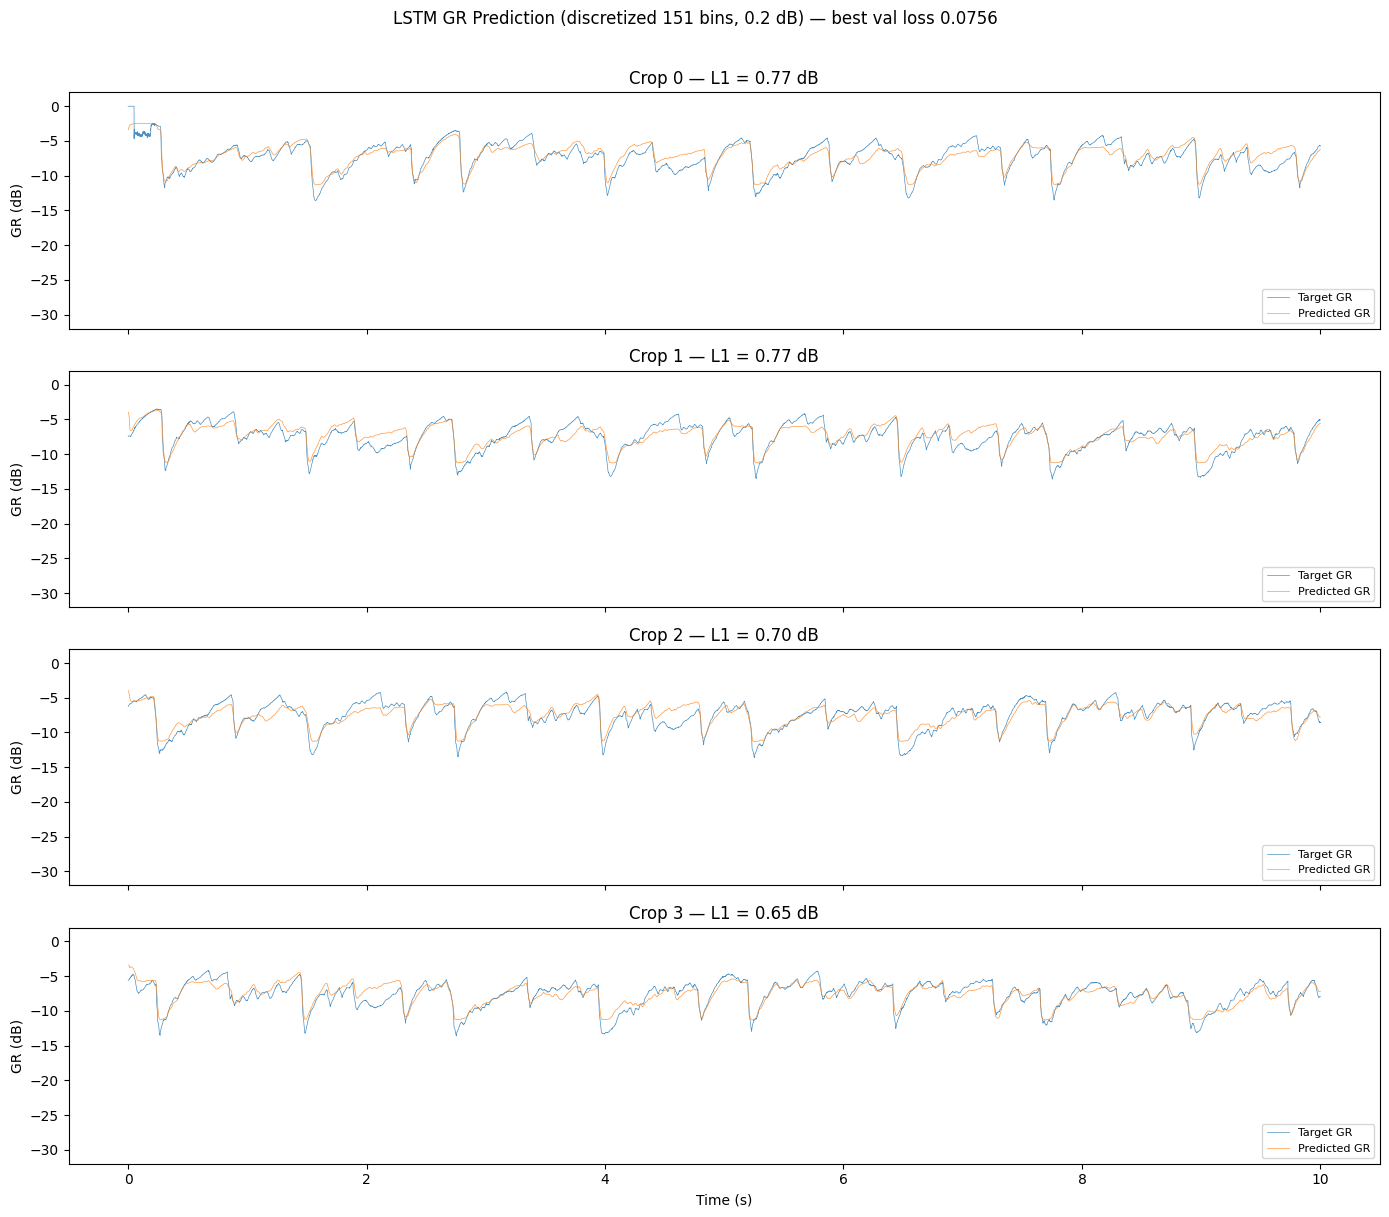

In [10]:
# ── 8. Evaluate: plot predicted vs target GR ─────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# Load best checkpoint weights
ckpt = torch.load(best_cb.best_model_path, map_location="cuda", weights_only=False)
system.load_state_dict(ckpt["state_dict"])
system.eval().cuda()
print(f"Loaded best checkpoint: {best_cb.best_model_path}")

# Run on a few validation crops
dm.setup()
val_dl = dm.val_dataloader()
batch = next(iter(val_dl))
dry, gr_db = batch[0].cuda(), batch[1].cuda()

with torch.no_grad(), torch.amp.autocast(device_type="cuda"):
    logits = system(dry)
    gr_pred_db = system.model.to_db(logits, T=dry.shape[-1])
    gr_target_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX)

gr_pred_db = gr_pred_db.cpu().numpy()
gr_target_db = gr_target_db.cpu().numpy()

n_plots = min(4, dry.shape[0])
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

t = np.arange(gr_pred_db.shape[-1]) / SAMPLE_RATE

for i, ax in enumerate(axes):
    ax.plot(t, gr_target_db[i, 0], label="Target GR", alpha=0.8, linewidth=0.5)
    ax.plot(t, gr_pred_db[i, 0], label="Predicted GR", alpha=0.8, linewidth=0.5)
    l1_db = np.mean(np.abs(gr_pred_db[i, 0] - gr_target_db[i, 0]))
    ax.set_ylabel("GR (dB)")
    ax.set_title(f"Crop {i} — L1 = {l1_db:.2f} dB")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(GR_DB_MIN - 2, 2)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"LSTM GR Prediction (discretized {GR_NUM_BINS} bins, {GR_BIN_RESOLUTION} dB) "
    f"— best val loss {best_cb.best_model_score:.4f}",
    y=1.01,
)
fig.tight_layout()

plot_path = os.path.join(RUN_DIR, "eval_gr_comparison.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot → {plot_path}")
plt.show()